In [ ]:
# 1. Import required libraries and set up HANA Cloud connection
from hana_ml import dataframe
import pandas as pd
import numpy as np
from hana_ml.dataframe import ConnectionContext
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split

# Connect to SAP HANA Cloud
cc = dataframe.ConnectionContext(
    "6291b51a-ea33-4ade-bb5c-0b8f1a032b9d.hana.demo-hc-3-hna0-hc-dev.dev-aws.hanacloud.ondemand.com",
    user="None",
    password="Abcd1234",
    port=443,
)

In [2]:
# 2. Generate dynamic synthetic data
num_features = 6
num_samples = 100
np.random.seed(42)
df = pd.DataFrame(
    np.random.rand(num_samples, num_features),
    columns=[f"F{i}" for i in range(num_features)]
)
df["TARGET"] = np.random.randint(0, 2, num_samples)
df["INDEX"] = range(num_samples)

print("First rows of generated DataFrame:")
print(df.head())

First rows of generated DataFrame:
         F0        F1        F2        F3        F4        F5  TARGET  INDEX
0  0.374540  0.950714  0.731994  0.598658  0.156019  0.155995       0      0
1  0.058084  0.866176  0.601115  0.708073  0.020584  0.969910       1      1
2  0.832443  0.212339  0.181825  0.183405  0.304242  0.524756       1      2
3  0.431945  0.291229  0.611853  0.139494  0.292145  0.366362       1      3
4  0.456070  0.785176  0.199674  0.514234  0.592415  0.046450       0      4


In [3]:
# 3. Save synthetic data to HANA Cloud
from hana_ml.dataframe import create_dataframe_from_pandas
create_dataframe_from_pandas(
    connection_context=cc,
    pandas_df=df,
    table_name='GENERATED_RDT_DATA_TBL',
    force=True
)

100%|██████████| 1/1 [00:00<00:00,  2.91it/s]


In [4]:
# 4. Load data from HANA table and define features/target
hana_table = cc.table('GENERATED_RDT_DATA_TBL')
hana_columns = hana_table.columns
target = 'TARGET'
features = [col for col in hana_columns if col not in [target, "INDEX"]]
key = "INDEX"
print("Used features:", features)

X = df[features].values
y = df[target].values

Used features: ['F0', 'F1', 'F2', 'F3', 'F4', 'F5']


In [5]:
# 5. Preprocessing pipeline for numeric features
X_df = df[features].copy()
X_df = X_df.replace({pd.NA: np.nan})

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler()),
    ('variance', VarianceThreshold(threshold=0.01))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features)
    ]
)

X_preprocessed = preprocessor.fit_transform(X_df)

In [6]:
# 6. Show data before and after preprocessing
print("Data before preprocessing:")
print(X[:5])
print("Data after preprocessing:")
print(X_preprocessed[:5])

Data before preprocessing:
[[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501 0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497 0.18340451 0.30424224 0.52475643]
 [0.43194502 0.29122914 0.61185289 0.13949386 0.29214465 0.36636184]
 [0.45606998 0.78517596 0.19967378 0.51423444 0.59241457 0.04645041]]
Data after preprocessing:
[[0.37464402 0.95705237 0.73959407 0.59205878 0.15223964 0.14977056]
 [0.05336284 0.87111933 0.60608827 0.70335038 0.0156548  0.98955553]
 [0.83952769 0.20649392 0.17838269 0.1696792  0.3017226  0.53025327]
 [0.43292411 0.28668564 0.61704168 0.12501506 0.28952222 0.36682424]
 [0.45741689 0.78878263 0.19658975 0.50618605 0.59234333 0.03674468]]


In [7]:
# 7. Train-test split
X_train_preprocessed, X_test_preprocessed, y_train, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, random_state=42
)

In [8]:
# 8. Import and initialize Random Decision Tree tool
from hana_ai.tools.hana_ml_tools.randomdecisiontree_tools import RDTTreeFitAndSave
rdt_tool = RDTTreeFitAndSave(cc)

In [9]:
# 9. Train the Random Decision Tree model
rdt_tool.run(tool_input={
    "name": "my_randomdecisiontree_model",
    "version": 1,
    "fit_table": "GENERATED_RDT_DATA_TBL",
    "target": target,
    "features": features,
    "n_estimators": 100,
    "max_depth": 6,
    "min_samples_leaf": 2,
    "random_state": 42,
    "thread_ratio": 0.5,
    "key": key
})

'{"status": "success", "model_name": "my_randomdecisiontree_model", "model_version": 1, "trained_table": "GENERATED_RDT_DATA_TBL"}'

In [10]:
# 10. Import and initialize prediction tool
from hana_ai.tools.hana_ml_tools.randomdecisiontree_tools import RDTTreeLoadModelAndPredict
rdt_predict_tool = RDTTreeLoadModelAndPredict(cc)

In [11]:
# 11. Run prediction tool
predictions = rdt_predict_tool.run(tool_input={
    "name": "my_randomdecisiontree_model",
    "version": 1,
    "predict_table": "GENERATED_RDT_DATA_TBL",
    "features": features,
    "key": key
})

import json
if isinstance(predictions, str):
    predictions_dict = json.loads(predictions)
else:
    predictions_dict = predictions

pred_df = pd.DataFrame(predictions_dict["predictions"])
print(pred_df.head())


   INDEX SCORE  CONFIDENCE
0      0     0        0.80
1      1     1        0.72
2      2     1        0.66
3      3     1        0.80
4      4     0        0.62


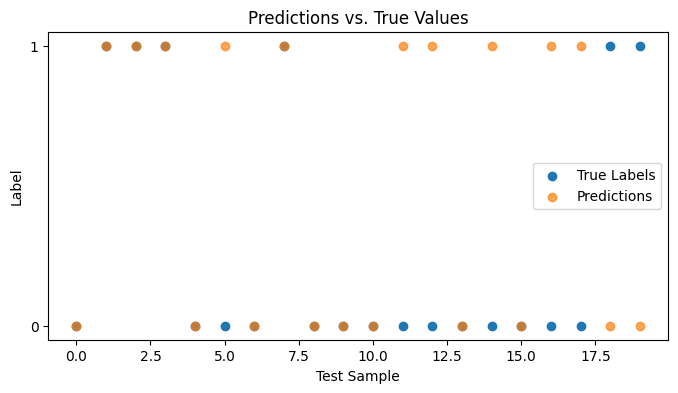

In [12]:
# 12. Postprocessing after prediction (Analysis & Visualization)
import matplotlib.pyplot as plt

if 'PREDICTION' in pred_df.columns:
    y_pred = pred_df['PREDICTION'].values
elif 'SCORE' in pred_df.columns:
    y_pred = pred_df['SCORE'].values
else:
    print("Available columns:", pred_df.columns)
    raise ValueError("Prediction column not found!")

min_len = min(len(y_test), len(y_pred))
plt.figure(figsize=(8,4))
plt.scatter(range(min_len), y_test[:min_len], label='True Labels')
plt.scatter(range(min_len), y_pred[:min_len], label='Predictions', alpha=0.7)
plt.legend()
plt.title('Predictions vs. True Values')
plt.xlabel('Test Sample')
plt.ylabel('Label')
plt.show()

In [13]:
# 13. Set up LangChain integration for LLM-based agent
from langchain.agents import initialize_agent, AgentType
from gen_ai_hub.proxy.langchain import init_llm

llm = init_llm('gpt-4o', temperature=0.0, max_tokens=1800)
tools = [rdt_tool, rdt_predict_tool]
agent_chain = initialize_agent(
    tools,
    llm,
    agent=AgentType.STRUCTURED_CHAT_ZERO_SHOT_REACT_DESCRIPTION,
)

/var/folders/s0/lpt_8gsd7mld2dfq18l7ryfm0000gn/T/ipykernel_23222/356561097.py:7: LangChainDeprecationWarning: LangChain agents will continue to be supported, but it is recommended for new use cases to be built with LangGraph. LangGraph offers a more flexible and full-featured framework for building agents, including support for tool-calling, persistence of state, and human-in-the-loop workflows. For details, refer to the `LangGraph documentation <https://langchain-ai.github.io/langgraph/>`_ as well as guides for `Migrating from AgentExecutor <https://python.langchain.com/docs/how_to/migrate_agent/>`_ and LangGraph's `Pre-built ReAct agent <https://langchain-ai.github.io/langgraph/how-tos/create-react-agent/>`_.
  agent_chain = initialize_agent(


In [14]:
# 14. Use agent for modeling task
agent_chain.invoke(f"""
    Train a Random Decision Tree model for synthetic binary classification.

    Data:
    - Table: GENERATED_RDT_DATA_TBL
    - Target variable: {target}
    - Features: {', '.join(features)}
    - Key: {key}

    Model Configuration:
    - Model name: my_randomdecisiontree_model
    - Version: 1
    - Number of trees: 100
    - Maximum depth: 6
    - Minimum samples per leaf: 2
    - Thread ratio: 0.5

    Note: Features are numeric and data is normalized where appropriate.
""")

{'input': '\n    Train a Random Decision Tree model for synthetic binary classification.\n\n    Data:\n    - Table: GENERATED_RDT_DATA_TBL\n    - Target variable: TARGET\n    - Features: F0, F1, F2, F3, F4, F5\n    - Key: INDEX\n\n    Model Configuration:\n    - Model name: my_randomdecisiontree_model\n    - Version: 1\n    - Number of trees: 100\n    - Maximum depth: 6\n    - Minimum samples per leaf: 2\n    - Thread ratio: 0.5\n\n    Note: Features are numeric and data is normalized where appropriate.\n',
 'output': "The Random Decision Tree model 'my_randomdecisiontree_model' has been successfully trained and saved with version 1 using the data from 'GENERATED_RDT_DATA_TBL'."}

In [15]:
# --- LangChain Agent Natural Language Test Cases ---

instruction = "Please provide all JSON outputs strictly without comments. Always specify the 'features' parameter as a non-empty list of column names. Always specify the 'key' parameter as the name of the index column (usually 'INDEX'). Always specify the correct target column name (usually 'TARGET')."

print("Test: Train a model that ignores features with less than 5% variance.")
agent_chain.invoke(f"""
    {instruction}
    Train a Random Decision Tree model for binary classification.
    Ignore features with less than 5% variance.
    Use max_depth=6 and n_estimators=100.
    Table: GENERATED_RDT_DATA_TBL
    Target: TARGET
    Features: {features}
    Key: INDEX
""")

print("Test: Predict only for rows where F1 > 0.8.")
agent_chain.invoke(f"""
    {instruction}
    Predict only for rows in GENERATED_RDT_DATA_TBL where F1 > 0.8.
    Use model my_randomdecisiontree_model version 1.
    Features: {features}
    Key: INDEX
""")

print("Test: Score the model and explain accuracy in one sentence.")
agent_chain.invoke(f"""
    {instruction}
    Score the model accuracy on the test set.
    Explain in one sentence what the accuracy means.
    Use model my_randomdecisiontree_model version 1.
    Table: GENERATED_RDT_DATA_TBL
    Target: TARGET
    Features: {features}
    Key: INDEX
""")

print("Test: Return feature importance sorted in descending order.")
agent_chain.invoke(f"""
    {instruction}
    Show feature importance for model my_randomdecisiontree_model version 1, sorted descending.
    Table: GENERATED_RDT_DATA_TBL
    Target: TARGET
    Features: {features}
    Key: INDEX
""")

Test: Train a model that ignores features with less than 5% variance.
Test: Predict only for rows where F1 > 0.8.
Test: Score the model and explain accuracy in one sentence.
Test: Return feature importance sorted in descending order.


{'input': "\n    Please provide all JSON outputs strictly without comments. Always specify the 'features' parameter as a non-empty list of column names. Always specify the 'key' parameter as the name of the index column (usually 'INDEX'). Always specify the correct target column name (usually 'TARGET').\n    Show feature importance for model my_randomdecisiontree_model version 1, sorted descending.\n    Table: GENERATED_RDT_DATA_TBL\n    Target: TARGET\n    Features: ['F0', 'F1', 'F2', 'F3', 'F4', 'F5']\n    Key: INDEX\n",
 'output': "Currently, I do not have the capability to directly show feature importance for a Random Decision Tree model. Typically, feature importance can be extracted from the model after training using specific libraries or tools that support this functionality. If you have access to the model's environment, you might be able to use a library like scikit-learn to extract and sort feature importances. If you need further assistance, please let me know!"}